# CRISP-DM: AI-Powered Healthcare Recommendation System
## With Explainable AI (XAI) & User Trust Evaluation

| | |
|---|---|
| **Author** | Salma Diaaeldeen |
| **Supervisor** | Dr. Ahmed Okasha |
| **Framework** | CRISP-DM (6 phases) |
| **Research Gap** | Black-box interpretability in healthcare AI |

> **Before running:** Upload `Training.csv` and `Testing.csv` to Colab, then run `!pip install shap -q` in the cell below.

In [1]:
# Install SHAP (required for explainability — Phase 5.6)
!pip install shap -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import warnings
warnings.filterwarnings('ignore')

from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import cross_val_score
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)

SEED = 42
np.random.seed(SEED)
print("All imports successful ✓")


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: C:\Users\Lenovo\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip
C:\Users\Lenovo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


All imports successful ✓


---
## PHASE 1: BUSINESS UNDERSTANDING

In [2]:
print("\n" + "=" * 60)
print("PHASE 1: BUSINESS UNDERSTANDING")
print("=" * 60)

print("""
RESEARCH CONTEXT
────────────────
Domain       : Healthcare AI / Recommendation Systems
Framework    : CRISP-DM (Cross-Industry Standard Process for
               Data Mining)
Research Gap : Existing disease prediction systems achieve high
               accuracy but lack explainability — patients and
               clinicians cannot understand WHY a recommendation
               is made ("black box" problem).

RESEARCH QUESTION
─────────────────
"Does providing Explainable AI (XAI) reasoning alongside disease
 predictions improve user trust and transparency compared to
 predictions alone?"

OBJECTIVES
──────────
1. Build an accurate symptom-based disease prediction model (ML)
2. Integrate XAI (SHAP) to explain per-patient predictions
3. Generate personalized health recommendations per disease
4. Evaluate model performance using standard ML metrics
5. Simulate a comparative user study:
     Group A → Prediction only
     Group B → Prediction + XAI Explanation + Recommendation

SUCCESS CRITERIA
────────────────
• Model accuracy ≥ 90%
• Cross-validation std < 0.05 (stable predictions)
• XAI explanations identify top 5 contributing symptoms per patient
• Group B shows higher perceived trust than Group A (user study)
""")


PHASE 1: BUSINESS UNDERSTANDING

RESEARCH CONTEXT
────────────────
Domain       : Healthcare AI / Recommendation Systems
Framework    : CRISP-DM (Cross-Industry Standard Process for
               Data Mining)
Research Gap : Existing disease prediction systems achieve high
               accuracy but lack explainability — patients and
               clinicians cannot understand WHY a recommendation
               is made ("black box" problem).

RESEARCH QUESTION
─────────────────
"Does providing Explainable AI (XAI) reasoning alongside disease
 predictions improve user trust and transparency compared to
 predictions alone?"

OBJECTIVES
──────────
1. Build an accurate symptom-based disease prediction model (ML)
2. Integrate XAI (SHAP) to explain per-patient predictions
3. Generate personalized health recommendations per disease
4. Evaluate model performance using standard ML metrics
5. Simulate a comparative user study:
     Group A → Prediction only
     Group B → Prediction + XAI Exp

---
## PHASE 2: DATA UNDERSTANDING

PHASE 2: DATA UNDERSTANDING

Training set shape  : (4920, 133)
Testing set shape   : (42, 133)
Number of diseases  : 41
Number of symptoms  : 132

Missing values (train): 0
Missing values (test) : 0

Disease Distribution:
prognosis
Fungal infection                           120
Allergy                                    120
GERD                                       120
Chronic cholestasis                        120
Drug Reaction                              120
Peptic ulcer diseae                        120
AIDS                                       120
Diabetes                                   120
Gastroenteritis                            120
Bronchial Asthma                           120
Hypertension                               120
Migraine                                   120
Cervical spondylosis                       120
Paralysis (brain hemorrhage)               120
Jaundice                                   120
Malaria                                    120
Chicken pox     

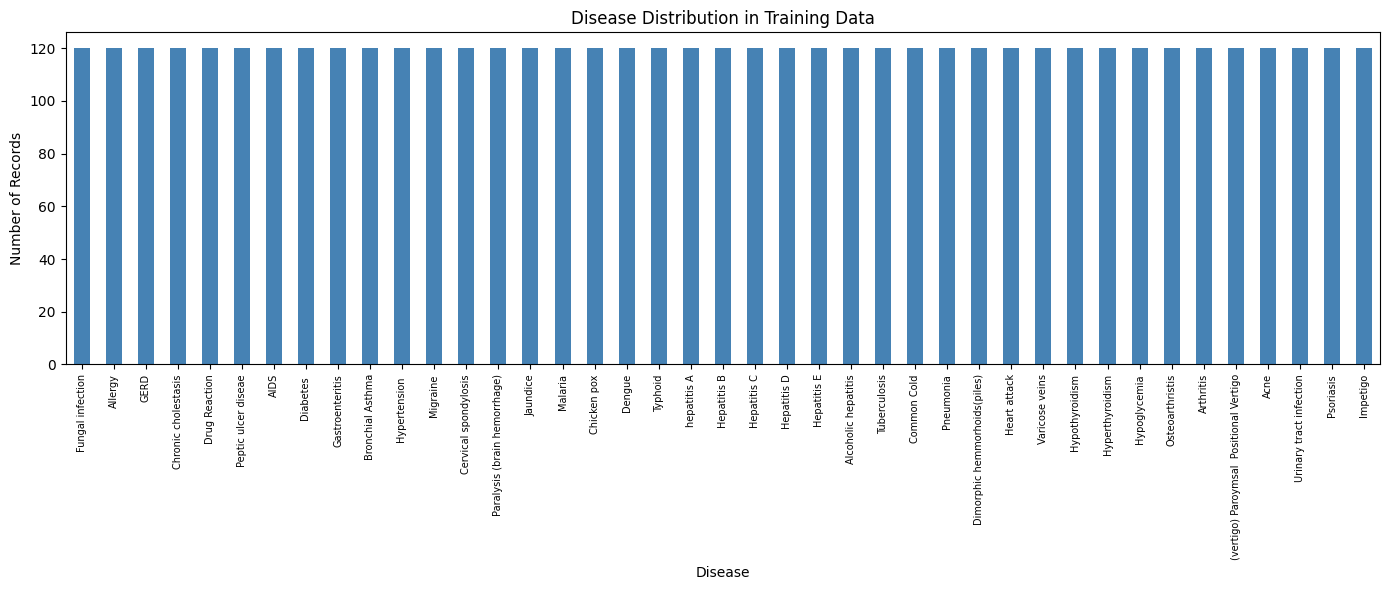


[DATA UNDERSTANDING NOTES]
• Dataset is perfectly balanced (120 samples/disease) — synthetic/curated
• No missing values — confirms controlled dataset
• Real-world note: actual clinical data is imbalanced & noisy
• 41 disease classes × 132 binary symptom features


In [3]:
print("=" * 60)
print("PHASE 2: DATA UNDERSTANDING")
print("=" * 60)

# Load data
train_df = pd.read_csv('Training.csv')
test_df  = pd.read_csv('Testing.csv')

# Drop unnamed columns
train_df = train_df.loc[:, ~train_df.columns.str.startswith('Unnamed')]
test_df  = test_df.loc[:, ~test_df.columns.str.startswith('Unnamed')]

# Basic info
print(f"\nTraining set shape  : {train_df.shape}")
print(f"Testing set shape   : {test_df.shape}")
print(f"Number of diseases  : {train_df['prognosis'].nunique()}")
print(f"Number of symptoms  : {train_df.shape[1] - 1}")
print(f"\nMissing values (train): {train_df.isnull().sum().sum()}")
print(f"Missing values (test) : {test_df.isnull().sum().sum()}")

# Disease distribution
print("\nDisease Distribution:")
print(train_df['prognosis'].value_counts())

plt.figure(figsize=(14, 6))
train_df['prognosis'].value_counts().plot(kind='bar', color='steelblue')
plt.title('Disease Distribution in Training Data')
plt.xlabel('Disease')
plt.ylabel('Number of Records')
plt.xticks(rotation=90, fontsize=7)
plt.tight_layout()
plt.show()

print("\n[DATA UNDERSTANDING NOTES]")
print("• Dataset is perfectly balanced (120 samples/disease) — synthetic/curated")
print("• No missing values — confirms controlled dataset")
print("• Real-world note: actual clinical data is imbalanced & noisy")
print("• 41 disease classes × 132 binary symptom features")

---
## PHASE 3: DATA PREPARATION

In [4]:
print("\n" + "=" * 60)
print("PHASE 3: DATA PREPARATION")
print("=" * 60)

# Define symptom columns
symptom_cols = [c for c in train_df.columns if c != 'prognosis']

# Prepare features
X_train = train_df[symptom_cols].values
X_test  = test_df[symptom_cols].values

# Encode target variable
label_encoder = LabelEncoder()
label_encoder.fit(train_df['prognosis'])
y_train = label_encoder.transform(train_df['prognosis'])
y_test  = label_encoder.transform(test_df['prognosis'])

id2label = dict(enumerate(label_encoder.classes_))

print(f"\nFeatures (symptoms) : {len(symptom_cols)}")
print(f"Disease classes     : {len(id2label)}")
print(f"Training samples    : {len(X_train)}")
print(f"Testing samples     : {len(X_test)}")
print(f"\nSample of encoded diseases:")
for i in list(id2label.items())[:5]:
    print(f"  {i[0]} → {i[1]}")
print("\nData preparation complete ✓")


PHASE 3: DATA PREPARATION

Features (symptoms) : 132
Disease classes     : 41
Training samples    : 4920
Testing samples     : 42

Sample of encoded diseases:
  0 → (vertigo) Paroymsal  Positional Vertigo
  1 → AIDS
  2 → Acne
  3 → Alcoholic hepatitis
  4 → Allergy

Data preparation complete ✓


---
## PHASE 4: MODELING

In [5]:
print("\n" + "=" * 60)
print("PHASE 4: MODELING")
print("=" * 60)

models = {
    "Decision Tree" : DecisionTreeClassifier(random_state=SEED),
    "KNN"           : KNeighborsClassifier(n_neighbors=5),
    "Random Forest" : RandomForestClassifier(n_estimators=200, random_state=SEED)
}

trained_models = {}

print("\nTraining models...")
for name, model in models.items():
    model.fit(X_train, y_train)
    trained_models[name] = model
    print(f"  {name} trained ✓")

print("\nModeling complete ✓")


PHASE 4: MODELING

Training models...
  Decision Tree trained ✓


  KNN trained ✓
  Random Forest trained ✓

Modeling complete ✓


---
## PHASE 5: EVALUATION

In [6]:
print("\n" + "=" * 60)
print("PHASE 5: EVALUATION")
print("=" * 60)


PHASE 5: EVALUATION


### 5.1 Accuracy Comparison


5.1 Model Accuracy:
---------------------------------------------
  Decision Tree: 97.62%
  KNN: 100.00%
  Random Forest: 97.62%


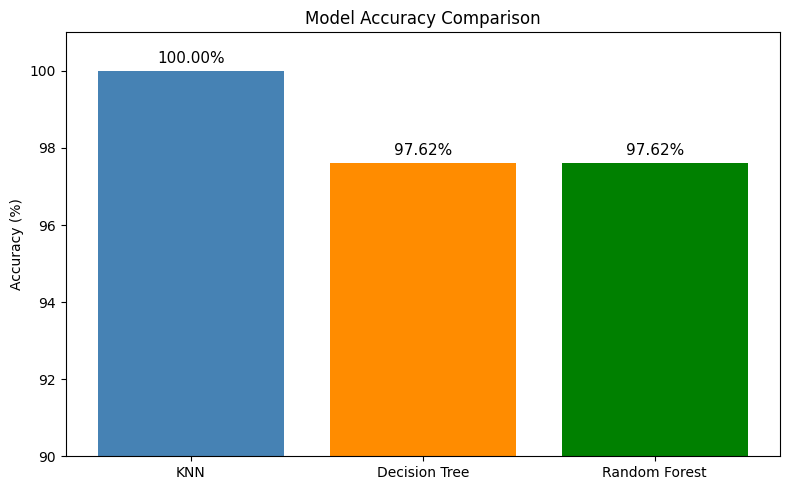

In [7]:
print("\n5.1 Model Accuracy:")
print("-" * 45)
results = []
for name, model in trained_models.items():
    predictions = model.predict(X_test)
    acc = accuracy_score(y_test, predictions)
    results.append({"Model": name, "Accuracy": acc})
    print(f"  {name}: {acc*100:.2f}%")

results_df = pd.DataFrame(results).sort_values("Accuracy", ascending=False)

plt.figure(figsize=(8, 5))
colors = ['steelblue', 'darkorange', 'green']
bars = plt.bar(results_df['Model'], results_df['Accuracy'] * 100, color=colors)
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy (%)')
plt.ylim([90, 101])
for bar, acc in zip(bars, results_df['Accuracy']):
    plt.text(bar.get_x() + bar.get_width()/2,
             acc * 100 + 0.2,
             f"{acc*100:.2f}%",
             ha='center', fontsize=11)
plt.tight_layout()
plt.show()

### 5.2 Cross Validation

In [8]:
print("\n5.2 5-Fold Cross Validation:")
print("-" * 45)
for name, model in models.items():
    cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')
    print(f"\n  {name}:")
    print(f"    Scores : {np.round(cv_scores, 4)}")
    print(f"    Mean   : {cv_scores.mean():.4f}")
    print(f"    Std    : {cv_scores.std():.4f}")


5.2 5-Fold Cross Validation:
---------------------------------------------

  Decision Tree:
    Scores : [1. 1. 1. 1. 1.]
    Mean   : 1.0000
    Std    : 0.0000

  KNN:
    Scores : [1. 1. 1. 1. 1.]
    Mean   : 1.0000
    Std    : 0.0000

  Random Forest:
    Scores : [1. 1. 1. 1. 1.]
    Mean   : 1.0000
    Std    : 0.0000


### 5.3 Classification Report (Best Model)

In [9]:
print("\n5.3 Classification Report (Random Forest):")
print("-" * 45)
best_model = trained_models["Random Forest"]
y_pred = best_model.predict(X_test)
print(classification_report(y_pred, y_test, target_names=label_encoder.classes_))


5.3 Classification Report (Random Forest):
---------------------------------------------
                                         precision    recall  f1-score   support

(vertigo) Paroymsal  Positional Vertigo       1.00      1.00      1.00         1
                                   AIDS       1.00      1.00      1.00         1
                                   Acne       1.00      1.00      1.00         1
                    Alcoholic hepatitis       1.00      1.00      1.00         1
                                Allergy       1.00      1.00      1.00         1
                              Arthritis       1.00      1.00      1.00         1
                       Bronchial Asthma       1.00      1.00      1.00         1
                   Cervical spondylosis       1.00      1.00      1.00         1
                            Chicken pox       1.00      1.00      1.00         1
                    Chronic cholestasis       1.00      1.00      1.00         1
                  

### 5.4 Confusion Matrix


5.4 Confusion Matrix (Random Forest):


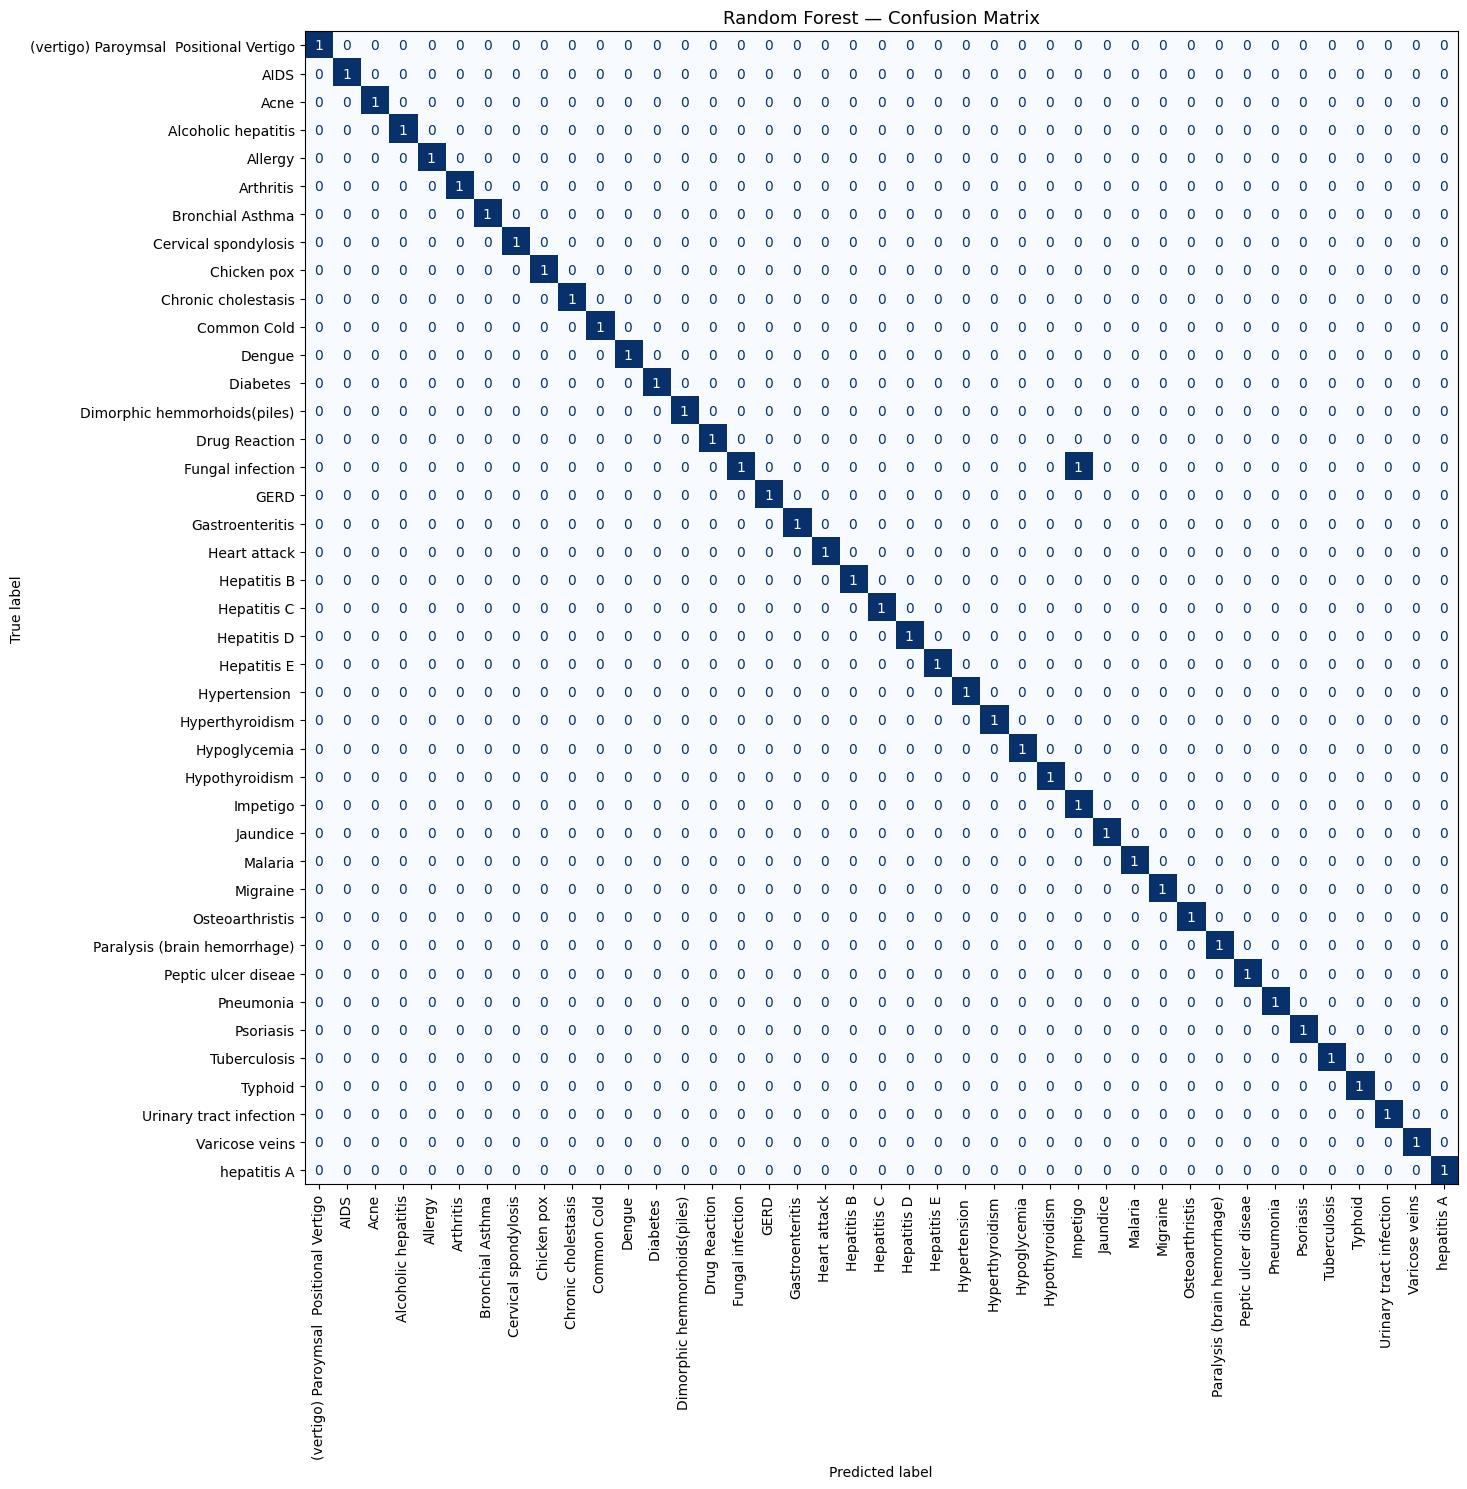

In [10]:
print("\n5.4 Confusion Matrix (Random Forest):")
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(18, 15))
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=label_encoder.classes_)
disp.plot(ax=ax, xticks_rotation=90, colorbar=False, cmap='Blues')
ax.set_title("Random Forest — Confusion Matrix", fontsize=13)
plt.tight_layout()
plt.show()

### 5.5 Global Feature Importance


5.5 Top 20 Most Important Symptoms (Global Feature Importance):
  muscle_pain: 1.95%
  itching: 1.69%
  dark_urine: 1.59%
  high_fever: 1.56%
  altered_sensorium: 1.49%
  fatigue: 1.46%
  nausea: 1.45%
  mild_fever: 1.43%
  yellowing_of_eyes: 1.41%
  family_history: 1.38%
  chest_pain: 1.37%
  sweating: 1.36%
  unsteadiness: 1.23%
  lack_of_concentration: 1.20%
  vomiting: 1.19%
  joint_pain: 1.19%
  diarrhoea: 1.13%
  breathlessness: 1.12%
  mucoid_sputum: 1.12%
  abdominal_pain: 1.10%


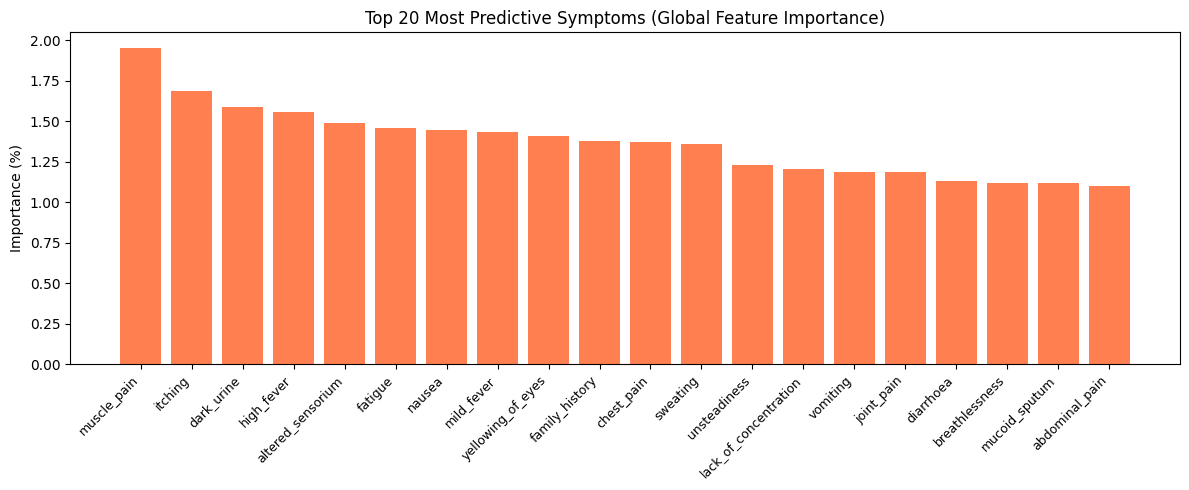

In [11]:
print("\n5.5 Top 20 Most Important Symptoms (Global Feature Importance):")
importances = best_model.feature_importances_
top_idx = np.argsort(importances)[::-1][:20]
top_symptoms = [(symptom_cols[i], importances[i]*100) for i in top_idx]
for sym, imp in top_symptoms:
    print(f"  {sym}: {imp:.2f}%")

plt.figure(figsize=(12, 5))
plt.bar(range(20), [importances[i]*100 for i in top_idx], color='coral')
plt.xticks(range(20),
           [symptom_cols[i] for i in top_idx],
           rotation=45, ha='right', fontsize=9)
plt.ylabel("Importance (%)")
plt.title("Top 20 Most Predictive Symptoms (Global Feature Importance)")
plt.tight_layout()
plt.show()

### 5.6 XAI: SHAP Local Explainability (NEW — addresses research gap)


5.6 XAI — SHAP Local Explainability (Per-Patient):
---------------------------------------------
Computing SHAP values for test set... (may take ~30 sec)
SHAP values computed ✓
SHAP output shape: (42, 132, 41)

[XAI RESEARCH NOTE]
──────────────────
• Global Feature Importance (5.5) = which symptoms matter OVERALL
• SHAP (5.6) = which symptoms drove THIS specific patient's prediction

This distinction is critical for your research gap:
  Patients need to understand WHY the system made a recommendation
  FOR THEM — not just what works in general.

SHAP directly addresses the "black box" interpretability problem
identified in your literature review.

Generating SHAP summary plot...


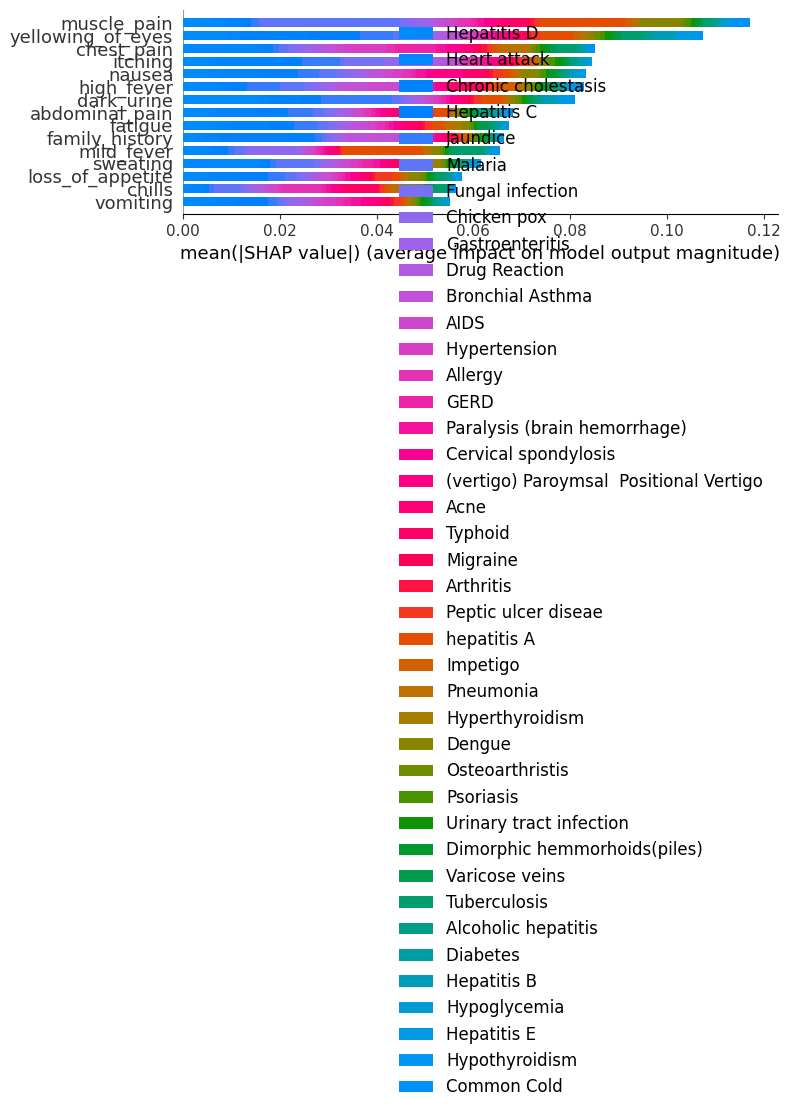

In [12]:
print("\n5.6 XAI — SHAP Local Explainability (Per-Patient):")
print("-" * 45)
print("Computing SHAP values for test set... (may take ~30 sec)")

explainer   = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test)   # shape: [n_classes, n_samples, n_features]

print("SHAP values computed ✓")
print(f"SHAP output shape: {np.array(shap_values).shape}")

print("""
[XAI RESEARCH NOTE]
──────────────────
• Global Feature Importance (5.5) = which symptoms matter OVERALL
• SHAP (5.6) = which symptoms drove THIS specific patient's prediction

This distinction is critical for your research gap:
  Patients need to understand WHY the system made a recommendation
  FOR THEM — not just what works in general.

SHAP directly addresses the "black box" interpretability problem
identified in your literature review.
""")

# SHAP summary plot — beeswarm (best for showing per-instance variation)
print("Generating SHAP summary plot...")
shap.summary_plot(shap_values, X_test,
                  feature_names=symptom_cols,
                  class_names=list(label_encoder.classes_),
                  max_display=15, plot_type="bar")

---
## PHASE 6: DEPLOYMENT

In [13]:
print("\n" + "=" * 60)
print("PHASE 6: DEPLOYMENT")
print("=" * 60)


PHASE 6: DEPLOYMENT


### 6.1 Health Recommendation Knowledge Base

In [14]:
print("\n6.1 Loading Health Recommendation Database...")

HEALTH_RECOMMENDATIONS = {
    "Fungal infection": (
        "Keep affected areas clean and dry. "
        "Use antifungal creams as prescribed. "
        "Avoid sharing personal items (towels, shoes). "
        "Consult a dermatologist if symptoms persist beyond 2 weeks."
    ),
    "Allergy": (
        "Identify and avoid allergens (dust, pollen, pet dander, foods). "
        "Take prescribed antihistamines. "
        "Keep a symptom diary to pinpoint triggers. "
        "Consult an allergist for skin-prick or blood tests."
    ),
    "GERD": (
        "Eat smaller, more frequent meals and avoid lying down within 3 hours of eating. "
        "Avoid spicy, fatty foods, caffeine, chocolate, and alcohol. "
        "Elevate the head of your bed by 15–20 cm. "
        "Take prescribed proton pump inhibitors (PPIs). "
        "Consult a gastroenterologist if symptoms are frequent."
    ),
    "Chronic cholestasis": (
        "Follow a low-fat diet and avoid alcohol completely. "
        "Take fat-soluble vitamin supplements (A, D, E, K) as prescribed. "
        "Monitor liver function tests regularly. "
        "Report any new symptoms (dark urine, pale stools) immediately to your doctor."
    ),
    "Drug Reaction": (
        "Stop the suspected medication immediately (seek medical guidance first). "
        "Seek emergency care if you experience breathing difficulty, swelling, or severe rash. "
        "Report the reaction to your doctor AND pharmacist. "
        "Carry a medical alert card listing the offending drug."
    ),
    "Peptic ulcer diseae": (
        "Avoid NSAIDs (ibuprofen, aspirin), alcohol, and smoking. "
        "Eat smaller, regular meals and avoid skipping meals. "
        "Take prescribed acid-reducing medications (PPIs or H2 blockers). "
        "Get tested for H. pylori infection — treatment eliminates most ulcers."
    ),
    "AIDS": (
        "Begin and adhere to antiretroviral therapy (ART) as prescribed — do not skip doses. "
        "Attend regular CD4 count and viral load monitoring. "
        "Maintain safe sexual practices and inform partners. "
        "Eat a nutritious diet and avoid infections. "
        "Join a peer support group for mental wellbeing."
    ),
    "Diabetes": (
        "Monitor blood glucose levels daily. "
        "Follow a low-sugar, high-fiber, balanced diet. "
        "Exercise at least 30 minutes per day (walking, swimming). "
        "Take medications or insulin as prescribed — never skip doses. "
        "Attend regular HbA1c checks and foot/eye examinations."
    ),
    "Gastroenteritis": (
        "Stay well hydrated — drink oral rehydration salts (ORS) frequently. "
        "Rest and eat bland foods (BRAT diet: Bananas, Rice, Applesauce, Toast). "
        "Avoid dairy, fatty, or spicy foods until recovered. "
        "Seek medical care if symptoms persist beyond 2 days or if you see blood in stool."
    ),
    "Bronchial Asthma": (
        "Use prescribed reliever inhaler (e.g., salbutamol) during attacks. "
        "Use preventer inhaler daily as prescribed. "
        "Identify and avoid triggers: dust, pollen, smoke, cold air. "
        "Maintain a clean, dust-free sleeping environment. "
        "Have an asthma action plan and carry rescue inhaler at all times."
    ),
    "Hypertension": (
        "Reduce daily salt intake to less than 5g. "
        "Exercise regularly (30 min/day, 5 days/week). "
        "Lose weight if overweight — even 5 kg can lower blood pressure significantly. "
        "Limit alcohol to no more than 1 unit/day. "
        "Take antihypertensive medications as prescribed and monitor blood pressure daily."
    ),
    "Migraine": (
        "Identify and avoid personal triggers (stress, caffeine withdrawal, bright lights, certain foods). "
        "Rest in a quiet, dark room at onset of attack. "
        "Take prescribed abortive medications early in the attack. "
        "Stay well hydrated and maintain a regular sleep schedule. "
        "Keep a headache diary to track patterns."
    ),
    "Cervical spondylosis": (
        "Perform gentle neck stretching and strengthening exercises daily. "
        "Use an ergonomic pillow and maintain good posture. "
        "Take regular breaks from screens and desk work (every 45 minutes). "
        "Apply heat or cold packs to relieve muscle tension. "
        "Consider physiotherapy or a neck collar (as advised by your doctor)."
    ),
    "Paralysis (brain hemorrhage)": (
        "THIS IS A MEDICAL EMERGENCY — call an ambulance immediately. "
        "After stabilization: attend intensive physiotherapy, occupational therapy, and speech therapy. "
        "Take prescribed anticoagulation or antihypertensive medications. "
        "Modify home environment for accessibility (grab rails, ramps). "
        "Join a stroke support group for long-term recovery."
    ),
    "Jaundice": (
        "Rest and maintain high fluid intake. "
        "Avoid alcohol completely — even small amounts can worsen liver damage. "
        "Follow a low-fat, easily digestible diet. "
        "Identify and treat the underlying cause (hepatitis, bile duct obstruction). "
        "Attend regular liver function tests until bilirubin normalizes."
    ),
    "Malaria": (
        "Take prescribed antimalarial medications and complete the FULL course. "
        "Rest and drink plenty of fluids. "
        "Use mosquito nets, repellents (DEET), and cover exposed skin at dusk/dawn. "
        "Seek immediate care if symptoms worsen (confusion, difficulty breathing)."
    ),
    "Chicken pox": (
        "Stay isolated from others (especially pregnant women and immunocompromised individuals). "
        "Apply calamine lotion or take antihistamines to relieve itching. "
        "Keep fingernails short and clean to prevent scratching and infection. "
        "Bathe daily in lukewarm water with baking soda. "
        "Seek medical advice if spots become infected or in high-risk groups."
    ),
    "Dengue": (
        "Rest and maintain very high fluid intake (coconut water, ORS, water). "
        "Monitor platelet count every 24–48 hours. "
        "Avoid aspirin, ibuprofen, and NSAIDs — they worsen bleeding risk. "
        "Seek immediate emergency care if you develop bleeding, severe abdominal pain, or persistent vomiting. "
        "Eliminate stagnant water around your home to prevent mosquito breeding."
    ),
    "Typhoid": (
        "Complete the full antibiotic course (ciprofloxacin or azithromycin) — do not stop early. "
        "Drink only boiled, bottled, or purified water. "
        "Maintain strict hand hygiene, especially before eating and after toilet use. "
        "Eat soft, easily digestible foods. "
        "Rest adequately and notify household contacts for testing."
    ),
    "hepatitis A": (
        "Rest and avoid alcohol completely. "
        "Maintain high fluid intake. "
        "Eat light, nutritious meals. "
        "Practice strict hand hygiene to prevent spreading to others. "
        "Recommend vaccination for close household contacts."
    ),
    "Hepatitis B": (
        "Avoid alcohol and hepatotoxic medications (check with your doctor). "
        "Take antiviral medications (e.g., tenofovir, entecavir) if prescribed. "
        "Ensure household contacts are vaccinated against Hepatitis B. "
        "Use protection to prevent transmission to partners. "
        "Attend regular liver function tests and viral load monitoring."
    ),
    "Hepatitis C": (
        "Complete the full direct-acting antiviral (DAA) treatment course (8–12 weeks). "
        "Avoid alcohol and any hepatotoxic drugs. "
        "Monitor liver function and viral load throughout treatment. "
        "Report to relevant health authorities if required in your country. "
        "Prevent transmission: do not share needles, razors, or toothbrushes."
    ),
    "Hepatitis D": (
        "Hepatitis D only occurs with Hepatitis B co-infection — treat both. "
        "Avoid alcohol. "
        "Take prescribed pegylated interferon therapy if indicated. "
        "Regular liver function monitoring and ultrasound every 6 months."
    ),
    "Hepatitis E": (
        "Rest and maintain adequate hydration. "
        "Avoid alcohol completely during illness. "
        "Eat a balanced, nutritious diet. "
        "The condition is typically self-limiting in immunocompetent patients (4–6 weeks). "
        "URGENT: Seek immediate medical care if pregnant — hepatitis E can be severe."
    ),
    "Alcoholic hepatitis": (
        "Stop alcohol consumption immediately and permanently — this is non-negotiable. "
        "Receive nutritional support (the liver needs protein and vitamins to heal). "
        "Take prescribed corticosteroids (prednisolone) if indicated by liver severity. "
        "Attend regular liver function monitoring. "
        "Seek addiction counseling or alcohol rehabilitation support."
    ),
    "Tuberculosis": (
        "Complete the full TB treatment course (6–9 months) — NEVER stop early. "
        "Take DOTS (Directly Observed Therapy Short-course) as required. "
        "Isolate during the infectious period (first 2 weeks of treatment). "
        "Ensure good ventilation in living and working spaces. "
        "All close contacts should be tested and potentially treated."
    ),
    "Common Cold": (
        "Rest and sleep adequately to allow immune recovery. "
        "Stay well hydrated (water, warm soups, herbal teas). "
        "Use saline nasal sprays to clear congestion. "
        "Take OTC decongestants or pain relievers as needed. "
        "Wash hands frequently and avoid close contact with vulnerable individuals."
    ),
    "Pneumonia": (
        "Complete the full prescribed antibiotic course (or antiviral if viral cause). "
        "Rest adequately — activity restriction for at least 1 week. "
        "Stay hydrated to help loosen secretions. "
        "Use a humidifier to ease breathing. "
        "Seek emergency care immediately if breathing worsens, lips turn blue, or confusion develops."
    ),
    "Dimorphic hemmorhoids(piles)": (
        "Increase dietary fiber intake (fruits, vegetables, whole grains) and drink 2–3L water/day. "
        "Take sitz baths (warm water) for 15 minutes, 2–3 times daily. "
        "Use prescribed topical ointments or suppositories for relief. "
        "Avoid straining during bowel movements — use a footstool if needed. "
        "Discuss surgical options (banding, hemorrhoidectomy) with your doctor if severe."
    ),
    "Heart attack": (
        "EMERGENCY: Call an ambulance immediately — do not drive yourself. "
        "Chew 300mg aspirin immediately if not allergic (unless contraindicated). "
        "After stabilization: begin cardiac rehabilitation and exercise program. "
        "Take prescribed medications (statins, beta-blockers, ACE inhibitors) consistently. "
        "Adopt heart-healthy lifestyle: Mediterranean diet, stop smoking, reduce stress."
    ),
    "Varicose veins": (
        "Elevate your legs above heart level for 15 minutes, 3 times daily. "
        "Wear graduated compression stockings as prescribed. "
        "Exercise regularly — walking strengthens calf muscles and improves circulation. "
        "Avoid prolonged standing or sitting; move and stretch every hour. "
        "Consult a vascular specialist for sclerotherapy, laser therapy, or phlebectomy."
    ),
    "Hypothyroidism": (
        "Take levothyroxine at the same time each day (ideally 30 min before breakfast). "
        "Do not take calcium or iron supplements within 4 hours of levothyroxine. "
        "Monitor TSH levels every 6–12 months (or after dose adjustments). "
        "Maintain a balanced diet — avoid excessive raw cruciferous vegetables. "
        "Report symptoms of over- or under-treatment to your doctor promptly."
    ),
    "Hyperthyroidism": (
        "Take prescribed antithyroid medications (methimazole or propylthiouracil). "
        "Use beta-blockers (e.g., propranolol) for symptom control if prescribed. "
        "Avoid excessive iodine (seaweed, iodine supplements). "
        "Attend regular thyroid function tests to monitor treatment. "
        "Discuss definitive options (radioactive iodine therapy or surgery) with your endocrinologist."
    ),
    "Hypoglycemia": (
        "IMMEDIATE: Consume fast-acting sugar — 15g glucose (3–4 glucose tablets, 150ml fruit juice). "
        "Retest blood glucose after 15 minutes; repeat if still low. "
        "Follow with a longer-acting carbohydrate snack (biscuit, bread). "
        "If unconscious: call emergency services — do not give food or drink. "
        "Review insulin or medication doses with your doctor to prevent recurrence."
    ),
    "Osteoarthristis": (
        "Exercise regularly — focus on low-impact activities (swimming, cycling, walking). "
        "Maintain a healthy weight — every 1 kg lost reduces knee joint load by 4 kg. "
        "Apply heat before exercise and cold packs after to manage pain and inflammation. "
        "Take prescribed anti-inflammatory medications or paracetamol for pain. "
        "Consider physiotherapy, assistive devices, or joint replacement surgery for severe cases."
    ),
    "Arthritis": (
        "Take prescribed disease-modifying antirheumatic drugs (DMARDs) or biologics as directed. "
        "Exercise regularly to maintain joint flexibility — avoid high-impact activities. "
        "Apply hot or cold compresses to affected joints for pain relief. "
        "Use assistive devices to protect joints during daily activities. "
        "Attend regular rheumatology follow-up and blood tests."
    ),
    "(vertigo) Paroymsal  Positional Vertigo": (
        "Perform the Epley maneuver with guidance from a physiotherapist — effective in 90% of cases. "
        "Avoid sudden head movements; move slowly when changing position (sitting up, turning in bed). "
        "Sleep with your head slightly elevated (2 pillows). "
        "Attend vestibular rehabilitation therapy if symptoms persist. "
        "Avoid driving or operating machinery during acute episodes."
    ),
    "Acne": (
        "Cleanse skin gently twice daily with a mild, non-comedogenic cleanser. "
        "Apply prescribed topical treatments (benzoyl peroxide, retinoids, antibiotics). "
        "Use non-comedogenic, oil-free moisturizers and sunscreen. "
        "Avoid touching, squeezing, or picking at spots — this causes scarring. "
        "Consult a dermatologist for moderate-to-severe acne or if OTC treatments fail."
    ),
    "Urinary tract infection": (
        "Complete the full prescribed antibiotic course — do not stop when symptoms improve. "
        "Drink at least 2 litres of water daily to flush bacteria. "
        "Urinate frequently — do not hold urine for long periods. "
        "Always wipe front to back after using the toilet. "
        "Follow-up urine culture 1 week after completing antibiotics to confirm clearance."
    ),
    "Psoriasis": (
        "Apply prescribed topical corticosteroids, vitamin D analogues, or retinoids to affected areas. "
        "Use thick emollients (moisturizers) generously to reduce scaling and itching. "
        "Avoid known triggers: stress, skin trauma, certain medications, alcohol. "
        "Consider narrowband UVB phototherapy for moderate-to-severe cases. "
        "Attend regular dermatology reviews — biologic therapies are available for severe disease."
    ),
    "Impetigo": (
        "Apply prescribed antibiotic cream (mupirocin) directly to sores 3 times daily. "
        "Keep infected areas clean, covered with sterile dressings. "
        "Avoid touching or scratching sores — this spreads the infection. "
        "Wash hands thoroughly and frequently. "
        "Stay away from school or work until 48 hours after starting antibiotic treatment."
    ),
}

print(f"✓ Health recommendation database loaded: {len(HEALTH_RECOMMENDATIONS)} diseases")

# Verify all diseases in dataset are covered
missing = set(id2label.values()) - set(HEALTH_RECOMMENDATIONS.keys())
if missing:
    print(f"⚠  Missing recommendations for: {missing}")
else:
    print("✓ All disease classes have recommendations")


6.1 Loading Health Recommendation Database...
✓ Health recommendation database loaded: 41 diseases
⚠  Missing recommendations for: {'Diabetes ', 'Hypertension '}


### 6.2 Prediction + XAI Explanation Function

In [15]:
def predict_with_explanation(symptom_vector, model, explainer_obj, shap_vals,
                              symptom_names, id2label_map, recommendations,
                              sample_idx, group="B", top_n=5):
    """
    Generate a prediction for one patient.

    Group A: returns disease name + confidence only.
    Group B: returns disease + confidence + SHAP explanation + recommendation.

    Parameters
    ----------
    symptom_vector : array-like, shape (n_symptoms,)
        Binary symptom presence vector for the patient.
    model          : fitted sklearn model
    explainer_obj  : shap.TreeExplainer fitted on model
    shap_vals      : precomputed SHAP values [n_classes, n_samples, n_features]
    symptom_names  : list of symptom column names
    id2label_map   : dict {int → disease name}
    recommendations: dict {disease name → recommendation string}
    sample_idx     : int, index of this sample in X_test
    group          : "A" or "B"
    top_n          : number of top SHAP features to display

    Returns
    -------
    dict with prediction details
    """
    pred_encoded = model.predict([symptom_vector])[0]
    pred_disease = id2label_map[pred_encoded]
    prob_all     = model.predict_proba([symptom_vector])[0]
    confidence   = prob_all[pred_encoded] * 100

    output = {
        "disease"    : pred_disease,
        "confidence" : confidence,
    }

        # Always include recommendation (both Group A and Group B)
    output["recommendation"] = recommendations.get(
        pred_disease, "Please consult a qualified healthcare professional."
    )

    if group == "B":
        # SHAP values for the predicted class at this sample
        sv = shap_vals[pred_encoded][sample_idx]

        # Top contributing symptoms (by absolute SHAP magnitude)
        top_indices  = np.argsort(np.abs(sv))[::-1][:top_n]
        top_features = [(symptom_names[i], sv[i]) for i in top_indices]

        output["top_symptoms"] = top_features

    return output



def display_patient_output(output, patient_id, group):
    """Pretty-print one patient's output in Group A or Group B format."""
    print(f"\n{'=' * 55}")
    print(f"  PATIENT {patient_id:02d} — GROUP {group} OUTPUT")
    print(f"{'=' * 55}")
    print(f"  Predicted Disease : {output['disease']}")
    print(f"  Confidence        : {output['confidence']:.1f}%")

        # Always show recommendation (both groups)
    print(f"\n  💊 Health Recommendation:")
    sentences = [s.strip() for s in output["recommendation"].split(".") if s.strip()]
    for sentence in sentences:
        print(f"     • {sentence}.")

    if group == "B":
        print(f"\n  📊 Why this prediction? (Top {len(output['top_symptoms'])} contributing symptoms):")
        for sym, val in output["top_symptoms"]:
            direction = "↑ Supports diagnosis" if val > 0 else "↓ Against diagnosis"
            print(f"     • {sym:<40} [{direction}, SHAP={val:+.4f}]")


    print("─" * 55)

### 6.3 User Study Simulation: Group A vs Group B

In [16]:
print("\n" + "=" * 60)
print("6.3 USER STUDY SIMULATION: Group A vs Group B")
print("=" * 60)

print("""
Study Design (Comparative)
──────────────────────────
Group A → receives: Disease prediction + confidence score
                    + Personalized health recommendation
Group B → receives: Disease prediction + confidence score
                    + Personalized health recommendation
                    + SHAP explanation (which symptoms drove prediction)


Research Hypothesis: Group B will report higher Trust and Transparency
""")

# Select 5 test patients
n_patients      = min(5, len(X_test))
patient_indices = np.random.choice(len(X_test), n_patients, replace=False)

print("─── GROUP A: Prediction-Only Output ───────────────────────")
for i, idx in enumerate(patient_indices):
    out = predict_with_explanation(
        X_test[idx], best_model, explainer, shap_values,
        symptom_cols, id2label, HEALTH_RECOMMENDATIONS,
        sample_idx=idx, group="A"
    )
    display_patient_output(out, patient_id=i + 1, group="A")

print("\n─── GROUP B: Prediction + XAI Explanation + Recommendation ─")
for i, idx in enumerate(patient_indices):
    out = predict_with_explanation(
        X_test[idx], best_model, explainer, shap_values,
        symptom_cols, id2label, HEALTH_RECOMMENDATIONS,
        sample_idx=idx, group="B"
    )
    display_patient_output(out, patient_id=i + 1, group="B")


6.3 USER STUDY SIMULATION: Group A vs Group B

Study Design (Comparative)
──────────────────────────
Group A → receives: Disease prediction + confidence score
                    + Personalized health recommendation
Group B → receives: Disease prediction + confidence score
                    + Personalized health recommendation
                    + SHAP explanation (which symptoms drove prediction)


Research Hypothesis: Group B will report higher Trust and Transparency

─── GROUP A: Prediction-Only Output ───────────────────────

  PATIENT 01 — GROUP A OUTPUT
  Predicted Disease : Tuberculosis
  Confidence        : 100.0%

  💊 Health Recommendation:
     • Complete the full TB treatment course (6–9 months) — NEVER stop early.
     • Take DOTS (Directly Observed Therapy Short-course) as required.
     • Isolate during the infectious period (first 2 weeks of treatment).
     • Ensure good ventilation in living and working spaces.
     • All close contacts should be tested and potenti

### 6.4 Simulated Trust & Transparency Scores

In [17]:
print("\n" + "=" * 60)
print("6.4 SIMULATED USER TRUST SCORES (Proof of Concept)")
print("=" * 60)

print("""
[IMPORTANT NOTE — SIMULATION]
These scores are SIMULATED to demonstrate the expected research outcome.
In your actual study:
  1. Recruit participants (patients / non-experts)
  2. Show Group A the prediction-only output
  3. Show Group B the full XAI output
  4. Ask each group to rate on a 5-point Likert scale:
       • "I trust this system's recommendation"         (1–5)
       • "I understand WHY this recommendation was made" (1–5)
       • "This information would help me take action"   (1–5)
  5. Replace the arrays below with your real survey data
""")


6.4 SIMULATED USER TRUST SCORES (Proof of Concept)

[IMPORTANT NOTE — SIMULATION]
These scores are SIMULATED to demonstrate the expected research outcome.
In your actual study:
  1. Recruit participants (patients / non-experts)
  2. Show Group A the prediction-only output
  3. Show Group B the full XAI output
  4. Ask each group to rate on a 5-point Likert scale:
       • "I trust this system's recommendation"         (1–5)
       • "I understand WHY this recommendation was made" (1–5)
       • "This information would help me take action"   (1–5)
  5. Replace the arrays below with your real survey data



### Simulated data (REPLACE with real survey responses)

✓ Loaded 15 responses
                 Timestamp      Age  Gender       Medical_Background  \
0   30‏/3‏/2026، 9:48:34 م  18 – 24  Female            No background   
1  30‏/3‏/2026، 10:09:22 م  25 – 34    Male  Healthcare professional   
2  30‏/3‏/2026، 10:10:04 م  35 – 44  Female   Some medical knowledge   
3  30‏/3‏/2026، 10:10:35 م      55+    Male  Healthcare professional   
4  30‏/3‏/2026، 10:13:03 م  25 – 34  Female            No background   

   AI_Comfort Q1_Preference Q2_Trust Q3_Clarity Q4_Useful Q5_Action  \
0           1             A        B          B         A         A   
1           4             B        E          B         B         E   
2           2             A        A          A         E         E   
3           1             A        A          B         B         B   
4           2             A        A          B         E         A   

   Q6_General_AI_Trust  Q7_XAI_Helpful XAI_In_Response Order_Code  
0                    2               2      Respon

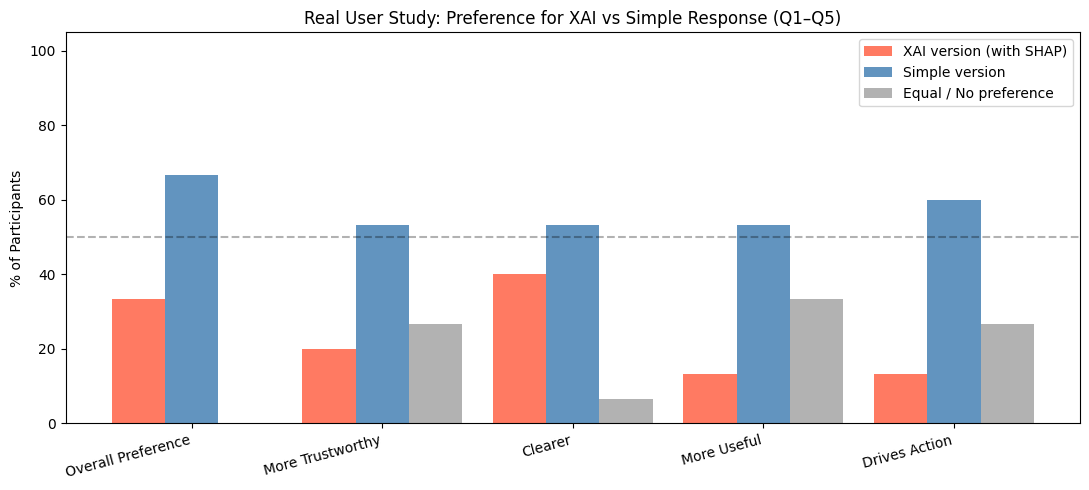

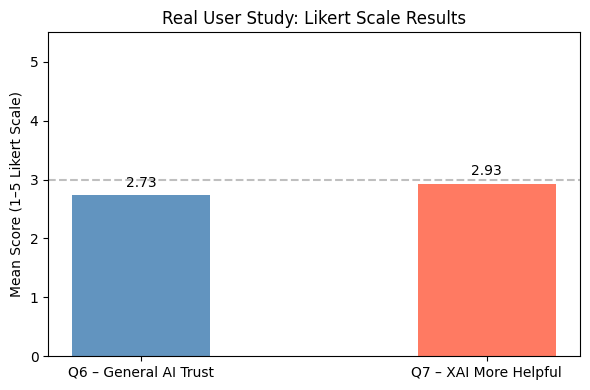

In [20]:
# np.random.seed(SEED)
# n_sim = 30  # simulated participants per group

# group_a_trust        = np.random.normal(3.1, 0.5, n_sim).clip(1, 5)
# group_a_transparency = np.random.normal(2.8, 0.6, n_sim).clip(1, 5)
# group_a_usefulness   = np.random.normal(3.0, 0.5, n_sim).clip(1, 5)

# group_b_trust        = np.random.normal(4.2, 0.4, n_sim).clip(1, 5)
# group_b_transparency = np.random.normal(4.5, 0.3, n_sim).clip(1, 5)
# group_b_usefulness   = np.random.normal(4.3, 0.4, n_sim).clip(1, 5)

# categories = ["Trust", "Transparency", "Usefulness"]
# a_means = [group_a_trust.mean(), group_a_transparency.mean(), group_a_usefulness.mean()]
# b_means = [group_b_trust.mean(), group_b_transparency.mean(), group_b_usefulness.mean()]

# print(f"{'Metric':<15} {'Group A (Pred only)':>22} {'Group B (Pred+XAI)':>22}  {'Improvement':>12}")
# print("-" * 75)
# for cat, a, b in zip(categories, a_means, b_means):
#     print(f"{cat:<15} {a:>22.2f} {b:>22.2f}  {'+' + f'{b-a:.2f}':>12}")

# # Bar chart: Group A vs Group B
# x = np.arange(len(categories))
# w = 0.35
# fig, ax = plt.subplots(figsize=(9, 5))
# bars_a = ax.bar(x - w/2, a_means, w,
#                 label='Group A (Prediction Only)',
#                 color='steelblue', alpha=0.85)
# bars_b = ax.bar(x + w/2, b_means, w,
#                 label='Group B (Prediction + XAI + Recommendation)',
#                 color='tomato', alpha=0.85)
# ax.set_ylabel('Mean Score (1–5 Likert Scale)')
# ax.set_title('User Study: Group A vs Group B\n'
#              '(Simulated — replace with real survey data)')
# ax.set_xticks(x)
# ax.set_xticklabels(categories)
# ax.set_ylim(0, 5.8)
# ax.legend()
# ax.bar_label(bars_a, fmt='%.2f', padding=3)
# ax.bar_label(bars_b, fmt='%.2f', padding=3)
# ax.axhline(y=3, color='gray', linestyle='--', alpha=0.5, label='Neutral (3/5)')
# plt.tight_layout()
# plt.show()

import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import numpy as np

# ── 1. Load real survey data ────────────────────────────────────────────────
# Upload your CSV (exported from Google Sheets) to Colab, then set the path:
df = pd.read_csv("survey_results.csv")

print(f"✓ Loaded {len(df)} responses")
print(df.head())

# ── 2. Normalize response labels ─────────────────────────────────────────────
# Each row tells us which label held the XAI content ("Response A" or "Response B")
# We map every Q1–Q5 answer to either "XAI" or "Simple" or "Equal"

def map_to_xai_or_simple(row, q_col):
    answer = row[q_col]          # "A", "B", or "E"
    xai_label = row["XAI_In_Response"].replace("Response ", "")   # "A" or "B"
    if answer == "E":
        return "Equal"
    elif answer == xai_label:
        return "XAI"
    else:
        return "Simple"

for q in ["Q1_Preference", "Q2_Trust", "Q3_Clarity", "Q4_Useful", "Q5_Action"]:
    df[q + "_mapped"] = df.apply(lambda row: map_to_xai_or_simple(row, q), axis=1)

# ── 3. Preference summary (Q1–Q5) ────────────────────────────────────────────
labels  = ["Overall Preference", "More Trustworthy", "Clearer",
           "More Useful", "Drives Action"]
q_cols  = ["Q1_Preference", "Q2_Trust", "Q3_Clarity", "Q4_Useful", "Q5_Action"]
n = len(df)

print("\n" + "=" * 65)
print("6.4  REAL USER STUDY RESULTS")
print("=" * 65)
print(f"\nTotal responses: {n}")
print(f"\n{'Metric':<22} {'XAI (with SHAP)':>16} {'Simple':>10} {'Equal':>8}")
print("-" * 60)

xai_pcts, simple_pcts, equal_pcts = [], [], []
for label, qc in zip(labels, q_cols):
    col = qc + "_mapped"
    xai_n    = (df[col] == "XAI").sum()
    simple_n = (df[col] == "Simple").sum()
    equal_n  = (df[col] == "Equal").sum()
    xai_pct    = xai_n    / n * 100
    simple_pct = simple_n / n * 100
    equal_pct  = equal_n  / n * 100
    xai_pcts.append(xai_pct)
    simple_pcts.append(simple_pct)
    equal_pcts.append(equal_pct)
    print(f"{label:<22} {xai_pct:>14.1f}%  {simple_pct:>8.1f}%  {equal_pct:>6.1f}%")

# ── 4. Q6 & Q7 Likert averages ───────────────────────────────────────────────
df["Q6_General_AI_Trust"] = pd.to_numeric(df["Q6_General_AI_Trust"], errors="coerce")
df["Q7_XAI_Helpful"]      = pd.to_numeric(df["Q7_XAI_Helpful"],      errors="coerce")

avg_q6 = df["Q6_General_AI_Trust"].mean()
avg_q7 = df["Q7_XAI_Helpful"].mean()
std_q6 = df["Q6_General_AI_Trust"].std()
std_q7 = df["Q7_XAI_Helpful"].std()

print(f"\nQ6 – General AI Trust  : {avg_q6:.2f} / 5  (SD = {std_q6:.2f})")
print(f"Q7 – XAI More Helpful  : {avg_q7:.2f} / 5  (SD = {std_q7:.2f})")

# ── 5. Chi-square test on Q1 (overall preference) ────────────────────────────
xai_q1    = (df["Q1_Preference_mapped"] == "XAI").sum()
simple_q1 = (df["Q1_Preference_mapped"] == "Simple").sum()
equal_q1  = (df["Q1_Preference_mapped"] == "Equal").sum()

chi2, p_val = stats.chisquare([xai_q1, simple_q1, equal_q1])
print(f"\nChi-square test (Q1 Overall Preference):")
print(f"  χ² = {chi2:.3f},  p = {p_val:.4f}  {'← significant (p < 0.05)' if p_val < 0.05 else ''}")

# ── 6. Bar chart: preference breakdown ───────────────────────────────────────
x   = np.arange(len(labels))
w   = 0.28
fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(x - w, xai_pcts,    w, label="XAI version (with SHAP)", color="tomato",    alpha=0.85)
ax.bar(x,     simple_pcts, w, label="Simple version",           color="steelblue", alpha=0.85)
ax.bar(x + w, equal_pcts,  w, label="Equal / No preference",    color="gray",      alpha=0.60)
ax.set_ylabel("% of Participants")
ax.set_title("Real User Study: Preference for XAI vs Simple Response (Q1–Q5)")
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=15, ha="right")
ax.set_ylim(0, 105)
ax.legend()
ax.axhline(y=50, color="black", linestyle="--", alpha=0.3, label="50% line")
plt.tight_layout()
plt.show()

# ── 7. Bar chart: Q6 & Q7 Likert means ───────────────────────────────────────
fig2, ax2 = plt.subplots(figsize=(6, 4))
bars = ax2.bar(["Q6 – General AI Trust", "Q7 – XAI More Helpful"],
               [avg_q6, avg_q7],
               color=["steelblue", "tomato"], alpha=0.85, width=0.4)
ax2.set_ylim(0, 5.5)
ax2.set_ylabel("Mean Score (1–5 Likert Scale)")
ax2.set_title("Real User Study: Likert Scale Results")
ax2.bar_label(bars, fmt="%.2f", padding=4)
ax2.axhline(y=3, color="gray", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()
